 # `vision_transformer.py` 워크스루

 [dino_training_walkthrough.py](dino_training_walkthrough.py) §4 "모델: backbone + DINOHead" 를
 읽기 전에 보는 **선행 자료**. ViT를 아래에서 위로 조립하며,
 매 단계를 저장소의 실제 모듈과 **수치로 대조**한다.

 ## 이 파일에 들어 있는 것

 `vision_transformer.py` 는 timm 의존 없이 ViT를 처음부터 구현한 373행짜리 파일이고,
 클래스 7개와 팩토리 3개가 전부다.

 ```
 drop_path()            함수      stochastic depth 본체
 DropPath               모듈      위 함수의 nn.Module 래퍼
 Mlp                    모듈      fc1 → GELU → fc2
 Attention              모듈      multi-head self-attention  ★ 어텐션 맵도 반환
 Block                  모듈      pre-norm residual x2 (Attention + Mlp)
 PatchEmbed             모듈      이미지 → 패치 토큰 (Conv2d 하나)
 VisionTransformer      모듈      위를 다 조립 + CLS/pos_embed + forward 3종
 DINOHead               모듈      MLP → L2 정규화 → weight_norm 선형층
 vit_tiny/small/base()  팩토리    하이퍼파라미터만 다른 3종
 ```

 ## 조립 순서 (아래에서 위로)

 ```
 이미지 (B,3,224,224)
    │
    ├─ §3  PatchEmbed          Conv2d(3→D, k=16, s=16) → (B,196,D)
    ├─ §4  CLS + pos_embed     (B,197,D)                ← 여기서 "순서"가 생긴다
    │
    │      §8 Block x depth ─────────────────────────────┐
    │        ├─ §5 Attention   softmax(QKᵀ/√d)V         │  ← 토큰끼리 섞이는 유일한 곳
    │        ├─ §6 Mlp         D → 4D → D               │  ← 토큰별로 독립
    │        └─ §7 DropPath    잔차 경로를 확률적으로 끔  │
    │      ─────────────────────────────────────────────┘
    │
    ├─ §9  LayerNorm → x[:, 0]  (B,D)                    ← CLS 토큰만 취함
    └─ §13 DINOHead             (B,K)                    ← DINO 학습용, 끝나면 버림
 ```

 ## 목차

 | § | 내용 | 대상 |
 |---|---|---|
 | 1 | 환경 준비 | — |
 | 2 | 큰 그림: 왜 이미지를 토큰으로 바꾸나 | — |
 | 3 | `PatchEmbed`: Conv 하나가 곧 패치 자르기 | `PatchEmbed` |
 | 4 | CLS 토큰과 위치 임베딩 (+ 해상도 보간) | `VisionTransformer.prepare_tokens` |
 | 5 | `Attention`: 토큰이 섞이는 유일한 곳 | `Attention` |
 | 6 | `Mlp`: 토큰별 비선형 변환 | `Mlp` |
 | 7 | `DropPath`: stochastic depth | `drop_path`, `DropPath` |
 | 8 | `Block`: pre-norm residual | `Block` |
 | 9 | `VisionTransformer`: 전체 조립과 파라미터 | `VisionTransformer.__init__` |
 | 10 | 초기화: `trunc_normal_` 의 함정 | `_init_weights`, `utils.trunc_normal_` |
 | 11 | forward 경로 3종 | `forward` 외 2개 |
 | 12 | 어텐션이 실제로 보는 것 (사전학습 vs 랜덤) | `get_last_selfattention` |
 | 13 | `DINOHead` — DINO 워크스루 §4로 가는 다리 | `DINOHead` |
 | 14 | 요약 · 함정 | — |

 **전제**: 이 저장소 안에서 실행. GPU 없어도 전부 돌아간다(§12만 조금 느림).

 ## 1. 환경 준비

 DINO 워크스루와 달리 여기서는 **프로세스 그룹이 필요 없다** —
 `DINOLoss` 를 쓰지 않으므로 `dist.all_reduce` 가 등장하지 않는다.

In [ ]:
import os, sys, math, warnings
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="torch.nn.utils.weight_norm")

REPO = Path.cwd().resolve()
while not (REPO / "vision_transformer.py").exists() and REPO != REPO.parent:
    REPO = REPO.parent
assert (REPO / "vision_transformer.py").exists(), "dino 저장소 안에서 실행하세요"
sys.path.insert(0, str(REPO))

import vision_transformer as vits
from vision_transformer import (
    drop_path, DropPath, Mlp, Attention, Block, PatchEmbed,
    VisionTransformer, DINOHead,
)
from utils import trunc_normal_

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(0)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.unicode_minus": False})

from matplotlib import font_manager
_avail = {f.name for f in font_manager.fontManager.ttflist}
_ko = next((f for f in ["NanumGothic", "Noto Sans CJK KR", "Noto Sans CJK JP",
                        "Malgun Gothic", "AppleGothic", "UnDotum"] if f in _avail), None)
if _ko:
    plt.rcParams["font.family"] = [_ko, "DejaVu Sans"]
else:
    print("! 한글 폰트를 찾지 못했습니다 — 그래프 라벨이 네모로 보일 수 있습니다")

# ── 이 워크스루에서 계속 쓰는 설정: ViT-Tiny/16, 224px
D, P, DEPTH, HEADS = 192, 16, 12, 3
IMG = 224
NPATCH = (IMG // P) ** 2

print(f"repo   : {REPO}")
print(f"torch  : {torch.__version__}  device={DEVICE}")
print(f"설정   : ViT-Tiny/{P}  embed_dim={D}  depth={DEPTH}  heads={HEADS}")
print(f"         {IMG}px 입력 → 패치 {NPATCH}개 → 토큰 {NPATCH+1}개 (CLS 포함)")

repo   : /home/sungwoo/projects/swcho/dino
torch  : 2.4.0+cu121  device=cuda
설정   : ViT-Tiny/16  embed_dim=192  depth=12  heads=3
         224px 입력 → 패치 196개 → 토큰 197개 (CLS 포함)


 ## 2. 큰 그림: 왜 이미지를 토큰으로 바꾸나

 트랜스포머는 **토큰 시퀀스** $\{z_1, \dots, z_N\}$, $z_i \in \mathbb{R}^{D}$ 만 다룬다.
 그래서 이미지를 시퀀스로 바꿔야 하는데, 픽셀 하나를 토큰으로 두면
 $224 \times 224 = 50176$ 개 토큰이 되고 어텐션이 $O(N^2) = 2.5\times10^9$ 로 폭발한다.

 ViT의 해법은 **$P \times P$ 패치를 토큰 하나로** 묶는 것이다.

 $$
 N = \frac{H}{P}\cdot\frac{W}{P},
 \qquad P=16,\ H=W=224 \ \Rightarrow\ N = 14 \times 14 = 196
 $$

 이것이 ViT의 유일한 이미지 특화 설계다. 그 뒤는 전부 표준 트랜스포머다.

 | 구성 요소 | 토큰끼리 섞이는가? | 파라미터를 토큰마다 따로 쓰는가? |
 |---|---|---|
 | `PatchEmbed` | 아니오 | 아니오 (모든 패치에 같은 Conv) |
 | `Attention` | **예** | 아니오 |
 | `Mlp` | 아니오 | 아니오 (모든 토큰에 같은 MLP) |
 | `LayerNorm` | 아니오 | 아니오 |

 **토큰이 서로 정보를 주고받는 곳은 `Attention` 하나뿐이다.**
 나머지는 전부 "토큰별로 똑같이" 적용되는 연산이다. 이 사실이 §4의
 위치 임베딩이 왜 필요한지를 설명해 준다.

 `patch_size` 를 16에서 8로 바꾸면 파라미터 수는 그대로인데
 토큰이 4배($196 \to 784$), 어텐션 행렬은 16배가 된다 — §5에서 실측한다.

 ## 3. `PatchEmbed`: Conv 하나가 곧 패치 자르기

 전체 구현이 이것뿐이다.

 ```python
 self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)

 def forward(self, x):
     x = self.proj(x).flatten(2).transpose(1, 2)
     return x
 ```

 논문의 서술은 "패치를 flatten 해서 선형 투영한다"인데,

 $$
 z_p = W_e\, \mathrm{vec}(x_p) + b_e,
 \qquad x_p \in \mathbb{R}^{P\times P\times C},\quad W_e \in \mathbb{R}^{D \times P^2C}
 $$

 **kernel_size = stride = $P$ 인 Conv2d가 정확히 이 연산이다.** 커널이 패치 경계에서
 겹치지 않고 딱 맞아떨어지므로, 각 출력 위치가 서로 겹치지 않는 패치 하나의 선형 변환이 된다.
 아래에서 `unfold` + `Linear` 로 손으로 만든 것과 같은지 확인한다.

 shape 변화:

 $$
 (B, 3, 224, 224) \xrightarrow{\text{Conv}} (B, D, 14, 14)
 \xrightarrow{\text{flatten(2)}} (B, D, 196) \xrightarrow{\text{transpose}} (B, 196, D)
 $$

In [ ]:
patch_embed = PatchEmbed(img_size=IMG, patch_size=P, in_chans=3, embed_dim=D)
x_img = torch.randn(2, 3, IMG, IMG)

# ── shape 추적
conv_out = patch_embed.proj(x_img)
print(f"입력            {tuple(x_img.shape)}")
print(f"proj (Conv2d)   {tuple(conv_out.shape)}   # (B, D, H/P, W/P)")
print(f"flatten(2)      {tuple(conv_out.flatten(2).shape)}")
tokens = patch_embed(x_img)
print(f"transpose(1,2)  {tuple(tokens.shape)}   <- PatchEmbed 최종 출력")
print(f"\nnum_patches={patch_embed.num_patches}  = ({IMG}/{P})^2 = {NPATCH}")

# ── "Conv == 패치 자르기 + 선형 투영" 을 수치로 증명
W = patch_embed.proj.weight          # (D, 3, P, P)
b = patch_embed.proj.bias            # (D,)
W_flat = W.reshape(D, -1)            # (D, 3*P*P)  ← 논문의 W_e

# unfold: 겹치지 않는 P x P 패치를 벡터로 뽑아냄
patches = F.unfold(x_img, kernel_size=P, stride=P)      # (B, 3*P*P, N)
patches = patches.transpose(1, 2)                        # (B, N, 3*P*P)
manual = patches @ W_flat.t() + b                        # (B, N, D)

print(f"\nunfold 결과     {tuple(patches.shape)}   # 패치 벡터 길이 3*{P}*{P}={3*P*P}")
print(f"수동 선형 투영  {tuple(manual.shape)}")
assert torch.allclose(manual, tokens, atol=1e-5), "Conv != 패치 선형 투영"
print(f"최대 오차 {(manual - tokens).abs().max():.2e}  →  Conv2d(k=s=P) == 패치 flatten + Linear ✔")

# ── 파라미터 수
print(f"\nPatchEmbed 파라미터: {sum(p.numel() for p in patch_embed.parameters()):,}"
      f"  = D x 3 x P x P + D = {D}x3x{P}x{P} + {D}")

입력            (2, 3, 224, 224)
proj (Conv2d)   (2, 192, 14, 14)   # (B, D, H/P, W/P)
flatten(2)      (2, 192, 196)
transpose(1,2)  (2, 196, 192)   <- PatchEmbed 최종 출력

num_patches=196  = (224/16)^2 = 196

unfold 결과     (2, 196, 768)   # 패치 벡터 길이 3*16*16=768
수동 선형 투영  (2, 196, 192)
최대 오차 2.92e-06  →  Conv2d(k=s=P) == 패치 flatten + Linear ✔

PatchEmbed 파라미터: 147,648  = D x 3 x P x P + D = 192x3x16x16 + 192


In [ ]:
# ── 해상도가 바뀌면 토큰 수만 바뀐다 (파라미터는 그대로)
print(f"{'입력':>10s} {'패치 격자':>12s} {'토큰 수(+CLS)':>14s} {'어텐션 원소 수':>16s}")
for size in [96, 224, 480]:
    for p in [16, 8]:
        pe = PatchEmbed(img_size=size, patch_size=p, embed_dim=D)
        n = pe.num_patches + 1
        print(f"{size:>7d}px {'patch'+str(p):>12s} {n:>14d} {HEADS*n*n:>16,d}")
print("\n같은 patch_size 안에서 파라미터 수는 해상도와 무관하다 (Conv 커널이 공유되므로).")

        입력        패치 격자     토큰 수(+CLS)         어텐션 원소 수
     96px      patch16             37            4,107
     96px       patch8            145           63,075
    224px      patch16            197          116,427
    224px       patch8            785        1,848,675
    480px      patch16            901        2,435,403
    480px       patch8           3601       38,901,603

같은 patch_size 안에서 파라미터 수는 해상도와 무관하다 (Conv 커널이 공유되므로).


 ## 4. CLS 토큰과 위치 임베딩

 `prepare_tokens` 가 하는 일은 세 줄이다.

 ```python
 x = self.patch_embed(x)                          # (B, N, D)
 cls_tokens = self.cls_token.expand(B, -1, -1)    # (B, 1, D)
 x = torch.cat((cls_tokens, x), dim=1)            # (B, N+1, D)
 x = x + self.interpolate_pos_encoding(x, w, h)   # 위치 정보 주입
 ```

 ### CLS 토큰

 `self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))` — **학습되는 벡터 하나**다.
 이미지에서 오는 정보가 전혀 없고, 어텐션을 통해 패치들로부터 정보를 모으는
 "읽기 전용 슬롯" 역할을 한다. 최종 출력은 `x[:, 0]`, 즉 이 토큰의 마지막 상태다.

 `expand` 는 메모리를 복사하지 않고 stride 0 으로 브로드캐스트만 한다 (`repeat` 과의 차이).

 ### 왜 위치 임베딩이 필요한가

 어텐션은 **순열 등변(permutation equivariant)** 이다. 토큰 순서를 바꿔도
 출력이 같은 순서로 따라 바뀔 뿐, "몇 번째 토큰인지"를 전혀 모른다.

 $$
 \mathrm{Attn}(\Pi Z) = \Pi\,\mathrm{Attn}(Z)\quad \text{for any permutation } \Pi
 $$

 따라서 위치 임베딩 없이는 패치를 뒤섞은 이미지와 원본이 **완전히 같은 CLS 출력**을 낸다.
 아래에서 이걸 실험으로 확인한다.

 $$
 z_i \leftarrow z_i + p_i, \qquad p \in \mathbb{R}^{(N+1)\times D}\ \text{(학습됨)}
 $$

In [ ]:
model = vits.vit_tiny(patch_size=P)
model.eval()

print(f"cls_token  {tuple(model.cls_token.shape)}   학습 대상: {model.cls_token.requires_grad}")
print(f"pos_embed  {tuple(model.pos_embed.shape)}  = (1, N+1, D) = (1, {NPATCH}+1, {D})")
print(f"cls_token 초기값 노름: {model.cls_token.norm():.4f}  (trunc_normal_(std=.02) 로 초기화)")

# ── expand 는 메모리를 복사하지 않는다
ct = model.cls_token.expand(8, -1, -1)
print(f"\ncls_token.expand(8,-1,-1) → {tuple(ct.shape)}, stride={ct.stride()}"
      f"  ← 0번 축 stride 0 = 복사 없음")

# ── prepare_tokens shape 추적
with torch.no_grad():
    t = model.prepare_tokens(x_img)
print(f"\nprepare_tokens({tuple(x_img.shape)}) → {tuple(t.shape)}")

cls_token  (1, 1, 192)   학습 대상: True
pos_embed  (1, 197, 192)  = (1, N+1, D) = (1, 196+1, 192)
cls_token 초기값 노름: 0.2883  (trunc_normal_(std=.02) 로 초기화)

cls_token.expand(8,-1,-1) → (8, 1, 192), stride=(0, 192, 1)  ← 0번 축 stride 0 = 복사 없음

prepare_tokens((2, 3, 224, 224)) → (2, 197, 192)


In [ ]:
# ── 실험: 위치 임베딩이 없으면 패치 순서를 모른다
blk = model.blocks[0]
blk.eval()

B = 1
with torch.no_grad():
    patch_tok = model.patch_embed(x_img[:B])                      # (1, N, D)
    cls = model.cls_token.expand(B, -1, -1)
    perm = torch.randperm(NPATCH)

    # (a) 위치 임베딩 없이
    z_plain = torch.cat((cls, patch_tok), dim=1)
    z_shuf = torch.cat((cls, patch_tok[:, perm]), dim=1)
    out_plain = model.norm(blk(z_plain))[:, 0]
    out_shuf = model.norm(blk(z_shuf))[:, 0]

    # (b) 위치 임베딩을 더한 뒤
    pos = model.interpolate_pos_encoding(z_plain, IMG, IMG)
    zp_plain = z_plain + pos
    zp_shuf = z_shuf + pos          # 섞인 토큰에 "제자리" 위치를 더함
    outp_plain = model.norm(blk(zp_plain))[:, 0]
    outp_shuf = model.norm(blk(zp_shuf))[:, 0]

d_plain = (out_plain - out_shuf).abs().max().item()
d_pos = (outp_plain - outp_shuf).abs().max().item()

print(f"pos_embed 없이 패치를 섞었을 때 CLS 출력 차이 : {d_plain:.3e}  ← 0 (구분 못 함)")
print(f"pos_embed 를 더한 뒤 섞었을 때 CLS 출력 차이  : {d_pos:.3e}  ← 유의미 (구분함)")
assert d_plain < 1e-5 < d_pos
print("\n어텐션은 순열 등변 → 위치 정보는 반드시 '입력에 더해서' 넣어야 한다 ✔")

pos_embed 없이 패치를 섞었을 때 CLS 출력 차이 : 8.345e-07  ← 0 (구분 못 함)
pos_embed 를 더한 뒤 섞었을 때 CLS 출력 차이  : 3.508e-03  ← 유의미 (구분함)

어텐션은 순열 등변 → 위치 정보는 반드시 '입력에 더해서' 넣어야 한다 ✔


 ### `interpolate_pos_encoding`: 임의 해상도 대응

 `pos_embed` 는 224px($14\times14$ 격자)에 맞춰 학습되지만, DINO는 96px local crop과
 480px 시각화도 같은 백본에 넣는다. 그래서 격자 크기가 다르면 **bicubic 보간**으로 늘린다.

 $$
 \underbrace{p_{1:N}}_{14\times14\times D} \xrightarrow{\text{bicubic}}
 \underbrace{p'_{1:N'}}_{h_0\times w_0\times D},
 \qquad w_0 = \frac{W}{P},\ h_0 = \frac{H}{P}
 $$

 CLS의 위치 임베딩 $p_0$ 는 격자에 속하지 않으므로 **보간에서 제외하고 그대로 붙인다**.

 코드에 `w0, h0 = w0 + 0.1, h0 + 0.1` 이라는 이상한 줄이 있는데,
 `scale_factor` 방식 보간에서 부동소수 오차로 출력 크기가 1 작아지는 것을 막는 방어 코드다
 ([dino#8](https://github.com/facebookresearch/dino/issues/8)). 바로 다음 줄의
 `assert int(w0) == patch_pos_embed.shape[-2]` 가 그 결과를 검증한다.

 `npatch == N and w == h` 면 보간을 건너뛰고 원본을 그대로 쓴다 — 224px 정사각 입력의 빠른 경로다.

In [ ]:
print(f"{'입력':>8s} {'격자':>8s} {'토큰':>7s} {'보간?':>7s}")
for size in [96, 224, 480]:
    xx = torch.randn(1, 3, size, size)
    with torch.no_grad():
        tt = model.prepare_tokens(xx)
    grid = size // P
    skipped = (grid * grid == NPATCH)
    print(f"{size:>5d}px {f'{grid}x{grid}':>8s} {tt.shape[1]:>7d} "
          f"{'건너뜀' if skipped else 'bicubic':>7s}")

# ── DINO의 local crop 96px 이 실제로 37 토큰이 되는지
with torch.no_grad():
    t96 = model.prepare_tokens(torch.randn(1, 3, 96, 96))
print(f"\n96px local crop → {t96.shape[1]} 토큰 = 패치 {(96//P)**2}개 + CLS 1개")
print("→ MultiCropWrapper 가 96px 묶음을 따로 forward 해도 같은 pos_embed 를 재사용할 수 있는 이유")

# ── 비정사각 입력도 된다
with torch.no_grad():
    trect = model.prepare_tokens(torch.randn(1, 3, 96, 224))
print(f"96x224 직사각 입력 → {trect.shape[1]} 토큰 = {(96//P)*(224//P)} + 1")

      입력       격자      토큰     보간?
   96px      6x6      37 bicubic
  224px    14x14     197     건너뜀
  480px    30x30     901 bicubic

96px local crop → 37 토큰 = 패치 36개 + CLS 1개
→ MultiCropWrapper 가 96px 묶음을 따로 forward 해도 같은 pos_embed 를 재사용할 수 있는 이유
96x224 직사각 입력 → 85 토큰 = 84 + 1
96x224 직사각 입력 → 85 토큰 = 84 + 1


 ## 5. `Attention`: 토큰이 섞이는 유일한 곳

 ### 수식

 입력 토큰 $Z \in \mathbb{R}^{N \times D}$ 에서 head $h$ 마다

 $$
 Q_h = Z W_h^{Q},\quad K_h = Z W_h^{K},\quad V_h = Z W_h^{V},
 \qquad W_h^{\bullet} \in \mathbb{R}^{D \times d_h},\ d_h = \frac{D}{\text{heads}}
 $$

 $$
 A_h = \mathrm{softmax}\!\left(\frac{Q_h K_h^{\top}}{\sqrt{d_h}}\right) \in \mathbb{R}^{N\times N},
 \qquad O_h = A_h V_h
 $$

 $$
 \mathrm{MHSA}(Z) = \big[O_1 \Vert \cdots \Vert O_{\text{heads}}\big]\, W^{O}
 $$

 $A_h$ 의 각 행은 합이 1인 확률분포다 — "토큰 $i$ 가 각 토큰에 얼마나 주의를 주는가".

 ### $\sqrt{d_h}$ 로 나누는 이유

 $q, k$ 의 성분이 독립이고 분산 1이면 $q^\top k$ 의 분산은 $d_h$ 에 비례한다.
 스케일링 없이 softmax에 넣으면 $d_h$ 가 커질수록 로짓이 커져 분포가 one-hot으로 포화되고
 gradient가 사라진다. 코드는 `self.scale = head_dim ** -0.5` 로 이를 상쇄한다.

 ### 구현의 특징

 ```python
 qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, C // self.num_heads).permute(2, 0, 3, 1, 4)
 q, k, v = qkv[0], qkv[1], qkv[2]
 ...
 return x, attn        # ★ 어텐션 맵을 항상 함께 반환
 ```

 - $Q, K, V$ 를 **선형층 하나**(`nn.Linear(dim, dim*3)`)로 한 번에 뽑아 GEMM 한 번으로 처리한다.
 - `reshape` → `permute(2,0,3,1,4)` 로 $(3, B, \text{heads}, N, d_h)$ 를 만들어 q/k/v 를 분리한다.
 - **`return x, attn`** 이 DINO 특유의 선택이다. 어텐션 시각화가 이 저장소의 핵심 산출물이라
   일부러 남겼고, 대가로 `F.scaled_dot_product_attention`(FlashAttention)을 쓸 수 없어
   $(B, \text{heads}, N, N)$ 행렬이 항상 메모리에 올라간다.

In [ ]:
attn_mod = Attention(D, num_heads=HEADS, qkv_bias=True)
attn_mod.eval()
dh = D // HEADS

print(f"dim={D}  num_heads={HEADS}  head_dim={dh}")
print(f"scale = head_dim^-0.5 = {attn_mod.scale}  (= 1/sqrt({dh}))")
print(f"qkv: Linear({D} → {D*3})   proj: Linear({D} → {D})")
print(f"파라미터 {sum(p.numel() for p in attn_mod.parameters()):,}"
      f"  = 4 x (D x D) + 4 x D = 4x{D}x{D} + 4x{D}")

z = torch.randn(1, NPATCH + 1, D)
with torch.no_grad():
    out, A = attn_mod(z)
print(f"\n입력 {tuple(z.shape)} → 출력 {tuple(out.shape)},  어텐션 {tuple(A.shape)}")
print(f"어텐션 행 합 = {A.sum(-1).mean():.6f}  (softmax 이므로 정확히 1)")
print(f"CLS 행 A[0,:,0,:] 의 최대 주의 비중: {A[0,:,0,:].max(-1).values.tolist()}")

dim=192  num_heads=3  head_dim=64
scale = head_dim^-0.5 = 0.125  (= 1/sqrt(64))
qkv: Linear(192 → 576)   proj: Linear(192 → 192)
파라미터 148,224  = 4 x (D x D) + 4 x D = 4x192x192 + 4x192

입력 (1, 197, 192) → 출력 (1, 197, 192),  어텐션 (1, 3, 197, 197)
어텐션 행 합 = 1.000000  (softmax 이므로 정확히 1)
CLS 행 A[0,:,0,:] 의 최대 주의 비중: [0.012874457985162735, 0.01277578342705965, 0.011338312178850174]


In [ ]:
# ── 가중치 행렬에서 수식대로 손으로 재현
with torch.no_grad():
    Wqkv, bqkv = attn_mod.qkv.weight, attn_mod.qkv.bias   # (3D, D), (3D,)
    Wq, Wk, Wv = Wqkv.split(D, dim=0)
    bq, bk, bv = bqkv.split(D, dim=0)

    Q = z @ Wq.t() + bq          # (1, N, D)
    K = z @ Wk.t() + bk
    V = z @ Wv.t() + bv

    heads_out, attns = [], []
    for h in range(HEADS):
        sl = slice(h * dh, (h + 1) * dh)
        Qh, Kh, Vh = Q[..., sl], K[..., sl], V[..., sl]      # (1, N, dh)
        logits = (Qh @ Kh.transpose(-2, -1)) * (dh ** -0.5)  # (1, N, N)
        Ah = logits.softmax(dim=-1)
        heads_out.append(Ah @ Vh)
        attns.append(Ah)
    O = torch.cat(heads_out, dim=-1)         # head concat → (1, N, D)
    manual_out = attn_mod.proj(O)            # W^O
    manual_A = torch.stack(attns, dim=1)     # (1, heads, N, N)

print(f"수동 출력 오차   : {(manual_out - out).abs().max():.2e}")
print(f"수동 어텐션 오차 : {(manual_A - A).abs().max():.2e}")
assert torch.allclose(manual_out, out, atol=1e-5)
assert torch.allclose(manual_A, A, atol=1e-6)
print("\n가중치에서 수식대로 재현한 결과가 모듈 출력과 일치 ✔")

# ── scale 이 없으면 어떻게 되는가
with torch.no_grad():
    Qh, Kh = Q[..., :dh], K[..., :dh]
    raw = Qh @ Kh.transpose(-2, -1)
    for name, s in [("scale 없음", 1.0), (f"scale=1/sqrt({dh})", dh ** -0.5)]:
        p = (raw * s).softmax(-1)
        H = -(p * p.clamp_min(1e-12).log()).sum(-1).mean()
        print(f"{name:>18s}: 로짓 std={raw.std()*s:6.3f}  어텐션 엔트로피={H:.3f} "
              f"(uniform={math.log(NPATCH+1):.3f})")

수동 출력 오차   : 6.71e-08
수동 어텐션 오차 : 2.79e-09

가중치에서 수식대로 재현한 결과가 모듈 출력과 일치 ✔
          scale 없음: 로짓 std= 2.658  어텐션 엔트로피=2.844 (uniform=5.283)
  scale=1/sqrt(64): 로짓 std= 0.332  어텐션 엔트로피=5.229 (uniform=5.283)


In [ ]:
# ── 어텐션 메모리는 토큰 수의 제곱 (patch_size 를 줄이면 폭발)
print(f"{'설정':>18s} {'토큰 N':>8s} {'어텐션 원소':>14s} {'fp32 메모리':>12s}")
HEADS_S = 6                      # ViT-S 의 head 수
for size, p in [(224, 16), (224, 8), (480, 8)]:
    n = (size // p) ** 2 + 1
    elems = HEADS_S * n * n      # 배치 1장 기준
    print(f"{f'ViT-S/{p} {size}px':>18s} {n:>8d} {elems:>14,d} {elems*4/2**20:>9.1f} MB")
print("\n배치 크기를 곱하면 그대로 늘어난다 — patch 8 + 큰 이미지에서 OOM 이 나는 이유.")
print("FlashAttention 은 이 행렬을 만들지 않지만, DINO는 시각화를 위해 일부러 만든다.")

                설정     토큰 N         어텐션 원소     fp32 메모리
    ViT-S/16 224px      197        232,854       0.9 MB
     ViT-S/8 224px      785      3,697,350      14.1 MB
     ViT-S/8 480px     3601     77,803,206     296.8 MB

배치 크기를 곱하면 그대로 늘어난다 — patch 8 + 큰 이미지에서 OOM 이 나는 이유.
FlashAttention 은 이 행렬을 만들지 않지만, DINO는 시각화를 위해 일부러 만든다.


 ## 6. `Mlp`: 토큰별 비선형 변환

 ```python
 self.fc1 = nn.Linear(in_features, hidden_features)   # D → 4D
 self.act = act_layer()                               # GELU
 self.fc2 = nn.Linear(hidden_features, out_features)  # 4D → D
 ```

 $$
 \mathrm{Mlp}(z) = W_2\,\mathrm{GELU}(W_1 z + b_1) + b_2,
 \qquad W_1 \in \mathbb{R}^{4D \times D},\ W_2 \in \mathbb{R}^{D \times 4D}
 $$

 `mlp_ratio=4` 는 `Block` 에서 `mlp_hidden_dim = int(dim * mlp_ratio)` 로 전달된다.
 `nn.Linear` 는 마지막 축에만 작용하므로 **모든 토큰에 같은 MLP가 독립적으로** 적용된다
 (토큰 간 정보 교환 없음).

 GELU는 $\mathrm{GELU}(x) = x\,\Phi(x)$ 로, ReLU와 달리 매끄럽고 음수 구간을 완전히 죽이지 않는다.

 파라미터를 세어 보면 MLP가 블록의 **약 2/3** 를 차지한다:
 어텐션 $4D^2$ vs MLP $8D^2$.

입력 (1, 197, 192) → fc1 (1, 197, 768) → 출력 (1, 197, 192)

한 Block 의 파라미터 구성 (D=192):
  Attention :   148,224  (33.3%)   ~ 4D^2 = 147,456
  Mlp       :   295,872  (66.5%)   ~ 8D^2 = 294,912
  LayerNorm :       768  ( 0.2%)
  합계      :   444,864

5번 토큰만 변경 → 출력이 바뀐 토큰: [5]
Mlp 는 토큰끼리 섞지 않는다 ✔  (Attention 이라면 전 토큰이 바뀐다)


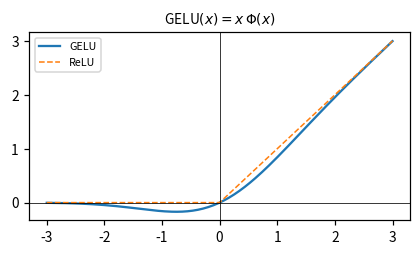

In [ ]:
mlp = Mlp(in_features=D, hidden_features=D * 4)
z1 = torch.randn(1, NPATCH + 1, D)
with torch.no_grad():
    print(f"입력 {tuple(z1.shape)} → fc1 {tuple(mlp.fc1(z1).shape)} → 출력 {tuple(mlp(z1).shape)}")

n_attn = sum(p.numel() for p in Attention(D, HEADS, qkv_bias=True).parameters())
n_mlp = sum(p.numel() for p in mlp.parameters())
n_ln = 2 * 2 * D          # norm1 + norm2 (weight + bias)
tot = n_attn + n_mlp + n_ln
print(f"\n한 Block 의 파라미터 구성 (D={D}):")
print(f"  Attention : {n_attn:>9,d}  ({100*n_attn/tot:4.1f}%)   ~ 4D^2 = {4*D*D:,}")
print(f"  Mlp       : {n_mlp:>9,d}  ({100*n_mlp/tot:4.1f}%)   ~ 8D^2 = {8*D*D:,}")
print(f"  LayerNorm : {n_ln:>9,d}  ({100*n_ln/tot:4.1f}%)")
print(f"  합계      : {tot:>9,d}")

# ── 토큰별 독립성 확인: 한 토큰만 바꾸면 그 토큰 출력만 바뀐다
with torch.no_grad():
    z2 = z1.clone(); z2[0, 5] += 10.0
    diff = (mlp(z2) - mlp(z1)).abs().amax(dim=-1)[0]
print(f"\n5번 토큰만 변경 → 출력이 바뀐 토큰: {(diff > 1e-6).nonzero().flatten().tolist()}")
print("Mlp 는 토큰끼리 섞지 않는다 ✔  (Attention 이라면 전 토큰이 바뀐다)")

# ── GELU 곡선
xs = torch.linspace(-3, 3, 200)
plt.figure(figsize=(4, 2.4))
plt.plot(xs, F.gelu(xs), label="GELU")
plt.plot(xs, F.relu(xs), "--", lw=1, label="ReLU")
plt.axhline(0, c="k", lw=.5); plt.axvline(0, c="k", lw=.5)
plt.legend(fontsize=7); plt.title(r"GELU$(x) = x\,\Phi(x)$", fontsize=9)
plt.tight_layout(); plt.show()

 ## 7. `DropPath`: stochastic depth

 ```python
 def drop_path(x, drop_prob=0., training=False):
     if drop_prob == 0. or not training:
         return x
     keep_prob = 1 - drop_prob
     shape = (x.shape[0],) + (1,) * (x.ndim - 1)      # (B, 1, 1) ← 샘플 단위
     random_tensor = keep_prob + torch.rand(shape, ...)
     random_tensor.floor_()                            # binarize
     output = x.div(keep_prob) * random_tensor
     return output
 ```

 Dropout이 **원소**를 끄는 것과 달리, DropPath는 **샘플 하나의 잔차 경로 전체**를 끈다.

 $$
 \tilde{x}_i = \frac{x_i}{1-p}\cdot m_i,
 \qquad m_i \sim \mathrm{Bernoulli}(1-p)
 $$

 `Block.forward` 에서 `x = x + self.drop_path(y)` 이므로, $m_i = 0$ 인 샘플은
 그 블록에서 **$x = x$, 즉 항등 함수**가 된다 — 네트워크 깊이가 샘플마다 확률적으로 줄어든다.

 ### 왜 $1-p$ 로 나누는가

 기대값을 보존해서 학습/추론 사이의 통계 차이를 없애기 위해서다 (inverted dropout).

 $$
 \mathbb{E}[\tilde{x}_i] = \frac{x_i}{1-p}\cdot(1-p) = x_i
 $$

 그래서 `eval()` 에서는 아무 보정 없이 `return x` 만 하면 된다.

 ### 깊이에 따라 선형 증가

 ```python
 dpr = [x.item() for x in torch.linspace(0, drop_path_rate, depth)]
 ```

 얕은 블록은 거의 끄지 않고, 깊은 블록일수록 많이 끈다.
 DINO 기본값은 `--drop_path_rate 0.1` 이고, **student에만** 적용한다
 (teacher는 gradient가 없으니 정규화가 필요 없다).

drop_prob=0.5
  살아남은 샘플 비율 : 0.5034   (기대값 1-p = 0.5)
  살아남은 값        : 2.0000   (= 1/(1-p) = 2.0)
  전체 평균          : 1.0069   (원본 1.0 과 일치 → 기대값 보존 ✔)
  eval 모드          : 원본과 동일? True

샘플별 상태 (B=6): ['OFF', 'ON', 'OFF', 'ON', 'OFF', 'OFF']
샘플 안에서 일부 원소만 꺼지는 일은 없다 — 잔차 경로 전체가 켜지거나 꺼진다.

drop_path_rate=0.1: 0.000 0.009 0.018 0.027 0.036 0.045 0.055 0.064 0.073 0.082 0.091 0.100

drop_path_rate=0.3: 0.000 0.027 0.055 0.082 0.109 0.136 0.164 0.191 0.218 0.245 0.273 0.300


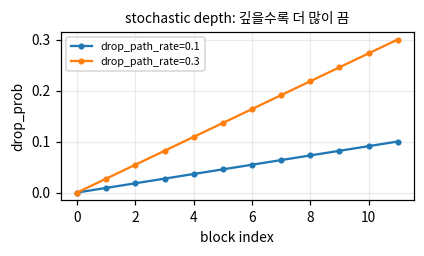


주의: Block 은 drop_path > 0 일 때만 DropPath 를 만들고, 0 이면 nn.Identity 다.
  블록 0 (dpr=0.0)  → Identity
  블록 11 (dpr=0.1) → DropPath


In [ ]:
p_drop = 0.5
xs = torch.ones(100000, 4, 8)          # 큰 배치로 기대값 확인

train_out = drop_path(xs, p_drop, training=True)
eval_out = drop_path(xs, p_drop, training=False)

alive = (train_out[:, 0, 0] != 0).float().mean().item()
print(f"drop_prob={p_drop}")
print(f"  살아남은 샘플 비율 : {alive:.4f}   (기대값 1-p = {1-p_drop})")
print(f"  살아남은 값        : {train_out.max():.4f}   (= 1/(1-p) = {1/(1-p_drop)})")
print(f"  전체 평균          : {train_out.mean():.4f}   (원본 1.0 과 일치 → 기대값 보존 ✔)")
print(f"  eval 모드          : 원본과 동일? {torch.equal(eval_out, xs)}")

# ── 마스크가 (B,1,1) 이라 샘플 단위로 통째로 꺼진다
one = drop_path(torch.ones(6, 3, 4), 0.5, training=True)
print(f"\n샘플별 상태 (B=6): {[('ON' if r.abs().sum()>0 else 'OFF') for r in one]}")
print("샘플 안에서 일부 원소만 꺼지는 일은 없다 — 잔차 경로 전체가 켜지거나 꺼진다.")

# ── depth 에 걸친 선형 증가
for rate in [0.1, 0.3]:
    dpr = [v.item() for v in torch.linspace(0, rate, DEPTH)]
    print(f"\ndrop_path_rate={rate}: " + " ".join(f"{v:.3f}" for v in dpr))

plt.figure(figsize=(4, 2.4))
for rate in [0.1, 0.3]:
    plt.plot(range(DEPTH), torch.linspace(0, rate, DEPTH), "-o", ms=3,
             label=f"drop_path_rate={rate}")
plt.xlabel("block index"); plt.ylabel("drop_prob")
plt.title("stochastic depth: 깊을수록 더 많이 끔", fontsize=9)
plt.legend(fontsize=7); plt.grid(alpha=.25)
plt.tight_layout(); plt.show()

print(f"\n주의: Block 은 drop_path > 0 일 때만 DropPath 를 만들고, 0 이면 nn.Identity 다.")
print(f"  블록 0 (dpr=0.0)  → {type(vits.vit_tiny(patch_size=P, drop_path_rate=0.1).blocks[0].drop_path).__name__}")
print(f"  블록 11 (dpr=0.1) → {type(vits.vit_tiny(patch_size=P, drop_path_rate=0.1).blocks[11].drop_path).__name__}")

 ## 8. `Block`: pre-norm residual

 ```python
 def forward(self, x, return_attention=False):
     y, attn = self.attn(self.norm1(x))
     if return_attention:
         return attn
     x = x + self.drop_path(y)
     x = x + self.drop_path(self.mlp(self.norm2(x)))
     return x
 ```

 $$
 \begin{aligned}
 x &\leftarrow x + \mathrm{DropPath}\big(\mathrm{MHSA}(\mathrm{LN}(x))\big)\\
 x &\leftarrow x + \mathrm{DropPath}\big(\mathrm{Mlp}(\mathrm{LN}(x))\big)
 \end{aligned}
 $$

 ### pre-norm 인 것이 중요하다

 LayerNorm이 **residual 안쪽**(서브레이어 입력)에 있다. 원 트랜스포머의 post-norm
 ($x \leftarrow \mathrm{LN}(x + \mathrm{sub}(x))$)과 달리, 입력에서 출력까지
 **정규화가 끼지 않은 순수 덧셈 경로**가 존재한다.

 $$
 x_L = x_0 + \sum_{l=1}^{L} f_l(x_{l-1})
 $$

 이 깨끗한 항등 경로 덕분에 gradient가 감쇠 없이 흐르고, warmup 없이도 깊은 모델이 학습된다.
 그래서 `VisionTransformer` 는 블록들을 지난 뒤 **마지막에 한 번 더** `self.norm` 을 적용한다
 (pre-norm 구조에서는 마지막 블록 출력이 정규화되지 않은 상태로 나오기 때문).

 ### `return_attention` 분기

 `Block` 이 어텐션만 반환할 수 있게 해 둔 덕분에,
 `get_last_selfattention` 이 마지막 블록만 이 모드로 불러 시각화 데이터를 얻는다.

In [ ]:
block = Block(dim=D, num_heads=HEADS, mlp_ratio=4., qkv_bias=True, drop_path=0.1,
              norm_layer=lambda d: nn.LayerNorm(d, eps=1e-6))
block.eval()

print("Block 구성:")
for name, m in block.named_children():
    n = sum(p.numel() for p in m.parameters())
    print(f"  {name:<10s} {type(m).__name__:<12s} {n:>9,d} params")

z = torch.randn(2, NPATCH + 1, D)
with torch.no_grad():
    y = block(z)
    a = block(z, return_attention=True)

print(f"\nforward             : {tuple(z.shape)} → {tuple(y.shape)}   (shape 불변)")
print(f"return_attention=True: {tuple(a.shape)}   (B, heads, N, N)")

# ── residual 이라 출력은 입력에서 크게 벗어나지 않는다
rel = ((y - z).norm() / z.norm()).item()
print(f"\n상대 변화량 ||y-x||/||x|| = {rel:.4f}  ← residual 이라 한 블록이 조금씩만 바꾼다")

# ── pre-norm: 잔차 경로에는 LN 이 없다
with torch.no_grad():
    y_attn, _ = block.attn(block.norm1(z))
    step1 = z + y_attn
    step2 = step1 + block.mlp(block.norm2(step1))
print(f"수동 재현 오차: {(step2 - y).abs().max():.2e}  (eval 이라 DropPath 는 항등)")
assert torch.allclose(step2, y, atol=1e-5)
print("pre-norm 두 줄을 그대로 재현 ✔")

Block 구성:
  norm1      LayerNorm          384 params
  attn       Attention      148,224 params
  drop_path  DropPath             0 params
  norm2      LayerNorm          384 params
  mlp        Mlp            295,872 params

forward             : (2, 197, 192) → (2, 197, 192)   (shape 불변)
return_attention=True: (2, 3, 197, 197)   (B, heads, N, N)

상대 변화량 ||y-x||/||x|| = 0.2061  ← residual 이라 한 블록이 조금씩만 바꾼다
수동 재현 오차: 0.00e+00  (eval 이라 DropPath 는 항등)
pre-norm 두 줄을 그대로 재현 ✔


 ## 9. `VisionTransformer`: 전체 조립

 `__init__` 이 만드는 것:

 | 이름 | 정체 | shape |
 |---|---|---|
 | `patch_embed` | `PatchEmbed` (Conv2d 하나) | — |
 | `cls_token` | `nn.Parameter` | $(1, 1, D)$ |
 | `pos_embed` | `nn.Parameter` | $(1, N{+}1, D)$ |
 | `pos_drop` | `nn.Dropout(drop_rate)` | — |
 | `blocks` | `nn.ModuleList` of `Block` × depth | — |
 | `norm` | `LayerNorm(eps=1e-6)` | — |
 | `head` | `Linear(D, num_classes)` 또는 **`Identity`** | — |

 `forward` 는 네 줄이다.

 ```python
 x = self.prepare_tokens(x)
 for blk in self.blocks:
     x = blk(x)
 x = self.norm(x)
 return x[:, 0]          # CLS 토큰만
 ```

 ### 세 가지 크기

 ```python
 def vit_tiny(patch_size=16, **kwargs):
     return VisionTransformer(patch_size=patch_size, embed_dim=192, depth=12, num_heads=3,
                              mlp_ratio=4, qkv_bias=True,
                              norm_layer=partial(nn.LayerNorm, eps=1e-6), **kwargs)
 ```

 세 팩토리의 차이는 `embed_dim` / `num_heads` 뿐이다 — `depth=12`, `mlp_ratio=4`,
 `qkv_bias=True`, `eps=1e-6` 는 공통이고 **head_dim 은 항상 64** 다.

 ### 눈여겨볼 기본값

 - `num_classes=0` → `self.head = nn.Identity()`. 즉 **DINO 백본은 처음부터 분류기가 없다**.
   (`MultiCropWrapper` 가 `backbone.fc, backbone.head = nn.Identity(), nn.Identity()` 로 한 번 더 덮는다.)
 - `img_size=[224]` — **리스트**다. `img_size[0]` 으로 꺼내 쓰므로 정수를 넘기면 깨진다.
 - `qkv_bias=True` 는 팩토리에서 주는 값이고, 클래스 기본값은 `False` 다.

In [ ]:
print(f"{'arch':>10s} {'embed_dim':>10s} {'depth':>6s} {'heads':>6s} {'head_dim':>9s} {'params':>10s}")
models = {}
for name in ["vit_tiny", "vit_small", "vit_base"]:
    m = vits.__dict__[name](patch_size=P)
    models[name] = m
    n = sum(p.numel() for p in m.parameters())
    hd = m.embed_dim // m.blocks[0].attn.num_heads
    print(f"{name:>10s} {m.embed_dim:>10d} {len(m.blocks):>6d} "
          f"{m.blocks[0].attn.num_heads:>6d} {hd:>9d} {n/1e6:>9.2f}M")

print(f"\nhead_dim 이 항상 64 로 고정 → num_heads = embed_dim / 64")
print(f"num_classes=0 이므로 head = {type(models['vit_tiny'].head).__name__}")

# ── 파라미터 breakdown
m = models["vit_tiny"]
groups = {"patch_embed": 0, "cls_token+pos_embed": 0, "blocks": 0, "norm": 0}
for n_, p_ in m.named_parameters():
    if n_.startswith("patch_embed"):
        groups["patch_embed"] += p_.numel()
    elif n_ in ("cls_token", "pos_embed"):
        groups["cls_token+pos_embed"] += p_.numel()
    elif n_.startswith("blocks"):
        groups["blocks"] += p_.numel()
    else:
        groups["norm"] += p_.numel()
tot = sum(groups.values())
print(f"\nViT-Tiny/{P} 파라미터 {tot:,} 구성:")
for k, v in groups.items():
    print(f"  {k:<22s} {v:>10,d}  ({100*v/tot:5.1f}%)")
print(f"\n블록 하나당 {groups['blocks']//DEPTH:,} x {DEPTH}개 → 거의 전부가 블록이다.")

# ── patch_size 는 파라미터 수를 거의 바꾸지 않는다
for p in [16, 8]:
    mm = vits.vit_small(patch_size=p)
    n = sum(q.numel() for q in mm.parameters())
    print(f"\nViT-S/{p}: params={n/1e6:.2f}M  pos_embed={tuple(mm.pos_embed.shape)}")
print("pos_embed 크기만 달라진다 (토큰 수가 다르므로). 연산량은 16배 차이.")

      arch  embed_dim  depth  heads  head_dim     params
  vit_tiny        192     12      3        64      5.52M
 vit_small        384     12      6        64     21.67M
  vit_base        768     12     12        64     85.80M

head_dim 이 항상 64 로 고정 → num_heads = embed_dim / 64
num_classes=0 이므로 head = Identity

ViT-Tiny/16 파라미터 5,524,416 구성:
  patch_embed               147,648  (  2.7%)
  cls_token+pos_embed        38,016  (  0.7%)
  blocks                  5,338,368  ( 96.6%)
  norm                          384  (  0.0%)

블록 하나당 444,864 x 12개 → 거의 전부가 블록이다.

ViT-S/16: params=21.67M  pos_embed=(1, 197, 384)

ViT-S/8: params=21.67M  pos_embed=(1, 785, 384)
pos_embed 크기만 달라진다 (토큰 수가 다르므로). 연산량은 16배 차이.


In [ ]:
# ── forward 를 손으로 재현
m = models["vit_tiny"]; m.eval()
xx = torch.randn(2, 3, IMG, IMG)
with torch.no_grad():
    t = m.prepare_tokens(xx)
    print(f"prepare_tokens        {tuple(t.shape)}")
    for i, blk in enumerate(m.blocks):
        t = blk(t)
    print(f"blocks x{DEPTH}           {tuple(t.shape)}")
    t = m.norm(t)
    print(f"norm (LayerNorm)      {tuple(t.shape)}")
    cls = t[:, 0]
    print(f"x[:, 0]  (CLS)        {tuple(cls.shape)}   <- VisionTransformer 출력")
    ref = m(xx)
assert torch.allclose(cls, ref, atol=1e-5)
print(f"\nmodel(x) 와 일치 ✔   최대 오차 {(cls-ref).abs().max():.2e}")
print(f"\n패치 토큰 {t.shape[1]-1}개는 forward 에서 버려진다 — "
      f"쓰려면 get_intermediate_layers 를 써야 한다 (§11).")

prepare_tokens        (2, 197, 192)
blocks x12           (2, 197, 192)
norm (LayerNorm)      (2, 197, 192)
x[:, 0]  (CLS)        (2, 192)   <- VisionTransformer 출력

model(x) 와 일치 ✔   최대 오차 0.00e+00

패치 토큰 196개는 forward 에서 버려진다 — 쓰려면 get_intermediate_layers 를 써야 한다 (§11).


 ## 10. 초기화: `trunc_normal_` 의 함정

 ```python
 trunc_normal_(self.pos_embed, std=.02)
 trunc_normal_(self.cls_token, std=.02)
 self.apply(self._init_weights)

 def _init_weights(self, m):
     if isinstance(m, nn.Linear):
         trunc_normal_(m.weight, std=.02)
         if m.bias is not None:
             nn.init.constant_(m.bias, 0)
     elif isinstance(m, nn.LayerNorm):
         nn.init.constant_(m.bias, 0)
         nn.init.constant_(m.weight, 1.0)
 ```

 - 모든 `Linear` 가중치: $\mathcal{N}(0, 0.02^2)$ 절단정규, bias는 0
 - 모든 `LayerNorm`: weight 1, bias 0
 - `cls_token`, `pos_embed` 도 같은 std로 초기화 (0이 아니다)
 - **`nn.Conv2d` 는 분기에 없다** → `PatchEmbed.proj` 는 PyTorch 기본 초기화
   (Kaiming uniform + nonzero bias)를 그대로 쓴다. 아래에서 확인한다.

 ### 함정: `a=-2, b=2` 는 $\sigma$ 단위가 아니다

 `trunc_normal_(tensor, mean=0., std=1., a=-2., b=2.)` 의 $a, b$ 는
 **절대값 경계**다. 내부 `_no_grad_trunc_normal_` 이

 ```python
 l = norm_cdf((a - mean) / std)      # std=0.02 → norm_cdf(-100) ≈ 0
 u = norm_cdf((b - mean) / std)      # → norm_cdf(+100) ≈ 1
 ```

 로 계산하므로, `std=.02` 에서는 경계가 $\pm 100\sigma$ 에 있어 **절단이 전혀 일어나지 않는다**.
 즉 DINO의 `trunc_normal_(m.weight, std=.02)` 는 사실상 평범한 정규분포 초기화다.
 `std=1.0` 으로 부르면 그때는 실제로 $\pm2$ 에서 잘린다. 아래에서 확인한다.

 이건 timm에서 그대로 가져온 관례라서 그렇고, 실질적 문제는 없다.
 다만 "절단정규니까 $\pm2\sigma$ 안에 있겠지"라고 가정하면 틀린다.

trunc_normal_(std=0.02): 실측 std=0.0200  max|w|=0.0886  = 4.43 sigma  → 절단 없음
trunc_normal_(std=1.0 ): 실측 std=0.8798  max|w|=2.0000  = 2.00 sigma  → 절단 있음

a=-2, b=2 는 절대 경계이므로 std=0.02 에서는 ±100 sigma → 절단 무효.

Linear weight : std=0.0200  mean=+0.00000  (목표 0.02)
Linear bias   : 전부 0? True
LayerNorm w/b : 전부 1/0? True / True

PatchEmbed Conv2d (=_init_weights 분기에 없음):
  weight std=0.0208  <- 0.02 가 아니다 (Kaiming uniform 기본값)
  bias 전부 0? False   max|b|=0.0360
  → nn.Conv2d 는 _init_weights 의 isinstance 검사(Linear/LayerNorm)에 걸리지 않는다.
cls_token     : std=0.0207  (0 이 아니라 trunc_normal_ 로 초기화)
pos_embed     : std=0.0200


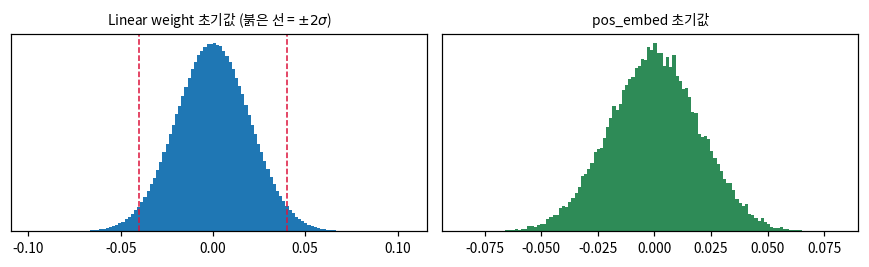

In [ ]:
# ── 절단이 실제로 일어나는지 확인
for std in [0.02, 1.0]:
    t = torch.zeros(200_000)
    trunc_normal_(t, std=std)
    print(f"trunc_normal_(std={std:<4}): 실측 std={t.std():.4f}  "
          f"max|w|={t.abs().max():.4f}  = {t.abs().max()/std:.2f} sigma  "
          f"→ 절단 {'있음' if t.abs().max() < 2.5*std else '없음'}")
print(f"\na=-2, b=2 는 절대 경계이므로 std=0.02 에서는 ±100 sigma → 절단 무효.")

# ── 실제 모델의 초기화 상태
m = vits.vit_tiny(patch_size=P)
lin_w = torch.cat([p.flatten() for n, p in m.named_parameters()
                   if n.endswith(".weight") and p.ndim == 2])
lin_b = torch.cat([p.flatten() for n, p in m.named_parameters()
                   if n.endswith(".bias") and "norm" not in n
                   and not n.startswith("patch_embed")])
ln_w = torch.cat([p.flatten() for n, p in m.named_parameters()
                  if "norm" in n and n.endswith(".weight")])
ln_b = torch.cat([p.flatten() for n, p in m.named_parameters()
                  if "norm" in n and n.endswith(".bias")])
conv_w, conv_b = m.patch_embed.proj.weight, m.patch_embed.proj.bias

print(f"\nLinear weight : std={lin_w.std():.4f}  mean={lin_w.mean():+.5f}  (목표 0.02)")
print(f"Linear bias   : 전부 0? {bool((lin_b == 0).all())}")
print(f"LayerNorm w/b : 전부 1/0? {bool((ln_w == 1).all())} / {bool((ln_b == 0).all())}")
print(f"\nPatchEmbed Conv2d (=_init_weights 분기에 없음):")
print(f"  weight std={conv_w.std():.4f}  <- 0.02 가 아니다 (Kaiming uniform 기본값)")
print(f"  bias 전부 0? {bool((conv_b == 0).all())}   max|b|={conv_b.abs().max():.4f}")
print(f"  → nn.Conv2d 는 _init_weights 의 isinstance 검사(Linear/LayerNorm)에 걸리지 않는다.")
print(f"cls_token     : std={m.cls_token.std():.4f}  (0 이 아니라 trunc_normal_ 로 초기화)")
print(f"pos_embed     : std={m.pos_embed.std():.4f}")

fig, ax = plt.subplots(1, 2, figsize=(8, 2.5))
ax[0].hist(lin_w.detach().numpy(), bins=120)
ax[0].axvline(0.04, ls="--", c="crimson", lw=1); ax[0].axvline(-0.04, ls="--", c="crimson", lw=1)
ax[0].set_title(r"Linear weight 초기값 (붉은 선 = $\pm2\sigma$)", fontsize=9)
ax[1].hist(m.pos_embed.detach().flatten().numpy(), bins=120, color="seagreen")
ax[1].set_title("pos_embed 초기값", fontsize=9)
for a in ax:
    a.set_yticks([])
fig.tight_layout(); plt.show()

 ## 11. forward 경로 3종

 같은 백본에서 세 가지 출력을 뽑을 수 있고, DINO의 각 스크립트가 골라 쓴다.

 | 메서드 | 출력 | 쓰는 곳 |
 |---|---|---|
 | `forward(x)` | $(B, D)$ — CLS 토큰 | 학습, k-NN, 검색 |
 | `get_last_selfattention(x)` | $(B, \text{heads}, N, N)$ | `visualize_attention.py`, `video_generation.py` |
 | `get_intermediate_layers(x, n)` | $n \times (B, N, D)$ | `eval_linear.py` |

 ### `get_last_selfattention`

 ```python
 for i, blk in enumerate(self.blocks):
     if i < len(self.blocks) - 1:
         x = blk(x)
     else:
         return blk(x, return_attention=True)
 ```

 마지막 블록만 `return_attention=True` 로 불러 어텐션 행렬을 반환한다.
 마지막 블록의 **출력은 계산되지 않는다** (어텐션까지만).

 ### `get_intermediate_layers`

 ```python
 for i, blk in enumerate(self.blocks):
     x = blk(x)
     if len(self.blocks) - i <= n:
         output.append(self.norm(x))
 ```

 마지막 $n$개 블록의 출력을 모으는데, **각각에 마지막 `self.norm` 을 적용**한다.
 `eval_linear.py` 는 여기서 각 층의 CLS를 꺼내 concat해

 $$
 \text{feature} = \big[\,\mathrm{CLS}^{(L-n+1)} \Vert \cdots \Vert \mathrm{CLS}^{(L)}\,\big]
 \in \mathbb{R}^{D\cdot n}
 $$

 를 linear probe 입력으로 쓴다 (ViT-S, $n=4$ → 1536차원).

In [ ]:
m = models["vit_small"]; m.eval()
xx = torch.randn(2, 3, IMG, IMG)

with torch.no_grad():
    f = m(xx)
    a = m.get_last_selfattention(xx)
    inter = m.get_intermediate_layers(xx, n=4)

print(f"forward                       → {tuple(f.shape)}")
print(f"get_last_selfattention        → {tuple(a.shape)}")
print(f"get_intermediate_layers(n=4)  → {len(inter)} x {tuple(inter[0].shape)}")

# ── linear probe 특징 구성
probe_feat = torch.cat([o[:, 0] for o in inter], dim=-1)
print(f"\nlinear probe 특징: {tuple(probe_feat.shape)} = D x n = {m.embed_dim} x 4")

# ── 마지막 중간층의 CLS == forward 출력 (둘 다 self.norm 적용됨)
print(f"inter[-1][:, 0] vs forward(x) 최대 오차: {(inter[-1][:,0] - f).abs().max():.2e}")
assert torch.allclose(inter[-1][:, 0], f, atol=1e-5)
print("→ get_intermediate_layers 의 마지막 원소가 forward 와 같은 지점이다 ✔")

# ── CLS 어텐션 행만 꺼내기 (시각화의 출발점)
cls_attn = a[:, :, 0, 1:]
print(f"\nCLS→패치 어텐션 a[:, :, 0, 1:] → {tuple(cls_attn.shape)}"
      f"  = (B, heads, 패치 {a.shape[-1]-1}개)")
print(f"행 합 = {cls_attn.sum(-1)[0].tolist()}  ← CLS→CLS 를 뺐으므로 1보다 작다")

forward                       → (2, 384)
get_last_selfattention        → (2, 6, 197, 197)
get_intermediate_layers(n=4)  → 4 x (2, 197, 384)

linear probe 특징: (2, 1536) = D x n = 384 x 4
inter[-1][:, 0] vs forward(x) 최대 오차: 0.00e+00
→ get_intermediate_layers 의 마지막 원소가 forward 와 같은 지점이다 ✔

CLS→패치 어텐션 a[:, :, 0, 1:] → (2, 6, 196)  = (B, heads, 패치 196개)
행 합 = [0.9950661659240723, 0.9946334958076477, 0.996025562286377, 0.9940536022186279, 0.9943249225616455, 0.9955400228500366]  ← CLS→CLS 를 뺐으므로 1보다 작다


 ## 12. 어텐션이 실제로 보는 것: 사전학습 vs 랜덤 초기화

 지금까지는 랜덤 초기화 모델을 봤다. 여기서 **공식 DINO 사전학습 가중치**를 불러
 같은 이미지의 어텐션을 비교한다. 이것이 DINO 논문의 대표 그림이다.

 `utils.load_pretrained_weights(model, "", None, "vit_small", 16)` 로 부르면
 파일 경로가 없을 때 `https://dl.fbaipublicfiles.com/dino/` 에서 자동 다운로드한다
 (약 86MB, 한 번 받으면 `~/.cache/torch/hub/checkpoints/` 에 캐시됨).

 > 이때 `Please use the --pretrained_weights argument ...` 라는 메시지가 찍히는데
 > **에러가 아니다** — 파일 경로가 아니면 일단 이 안내를 출력하고 나서 공식 URL로 넘어가는
 > 코드 흐름 때문이다 ([utils.py:83](../utils.py#L83)).

 정량 지표로 **CLS 어텐션의 엔트로피**를 본다.

 $$
 H(a^{(h)}) = -\sum_{i=1}^{N} \hat{a}^{(h)}_i \log \hat{a}^{(h)}_i,
 \qquad \hat{a}^{(h)} = \frac{a^{(h)}}{\sum_i a^{(h)}_i}
 $$

 랜덤 초기화는 모든 패치를 고르게 보므로 $H \approx \log N$ 이고,
 사전학습된 모델은 특정 영역에 집중하므로 $H$ 가 확실히 낮다.

In [ ]:
import utils as dino_utils
from PIL import Image
from torchvision import transforms

ARCH_V, PATCH_V = "vit_small", 16
eval_tf = transforms.Compose([
    transforms.Resize(256, interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.CenterCrop(IMG),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
])
MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
STD = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
denorm = lambda t: (t.cpu() * STD + MEAN).clamp(0, 1).permute(1, 2, 0).numpy()

img_path = REPO / "out/dino_attn/img.png"
if not img_path.exists():
    img_path = next((REPO / "out").rglob("*.png"), None)
raw = Image.open(img_path).convert("RGB")
img = eval_tf(raw).unsqueeze(0).to(DEVICE)
wf = IMG // PATCH_V

def cls_attention(model):
    model.eval().to(DEVICE)
    with torch.no_grad():
        a = model.get_last_selfattention(img)
    nh = a.shape[1]
    return a[0, :, 0, 1:].reshape(nh, wf, wf).cpu()

rand_model = vits.__dict__[ARCH_V](patch_size=PATCH_V)
attn_rand = cls_attention(rand_model)

pre_model = vits.__dict__[ARCH_V](patch_size=PATCH_V)
try:
    dino_utils.load_pretrained_weights(pre_model, "", None, ARCH_V, PATCH_V)
    attn_pre, have_pre = cls_attention(pre_model), True
except Exception as e:
    print(f"! 사전학습 가중치를 불러오지 못했습니다 ({type(e).__name__}) — 랜덤만 표시합니다")
    attn_pre, have_pre = None, False

def attn_entropy(a):
    p = a.flatten(1)
    p = p / p.sum(-1, keepdim=True)
    return (-(p * p.clamp_min(1e-12).log()).sum(-1))

print(f"\n패치 격자 {wf}x{wf} = {wf*wf}개,  log N = {math.log(wf*wf):.3f}")
print(f"랜덤 초기화   CLS 어텐션 엔트로피: {attn_entropy(attn_rand).mean():.3f}")
if have_pre:
    print(f"DINO 사전학습 CLS 어텐션 엔트로피: {attn_entropy(attn_pre).mean():.3f}  ← 낮을수록 집중")

Please use the `--pretrained_weights` argument to indicate the path of the checkpoint to evaluate.
Since no pretrained weights have been provided, we load the reference pretrained DINO weights.

패치 격자 14x14 = 196개,  log N = 5.278
랜덤 초기화   CLS 어텐션 엔트로피: 5.274
DINO 사전학습 CLS 어텐션 엔트로피: 4.263  ← 낮을수록 집중


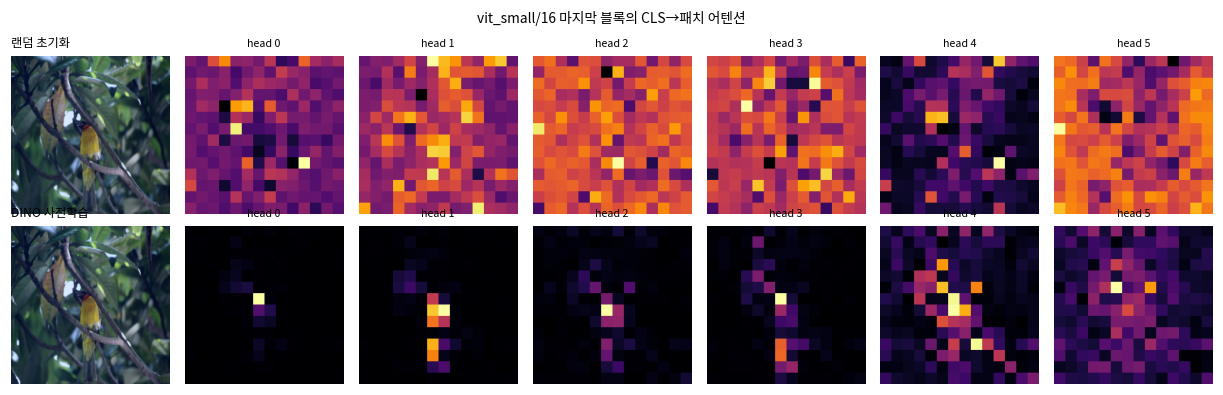

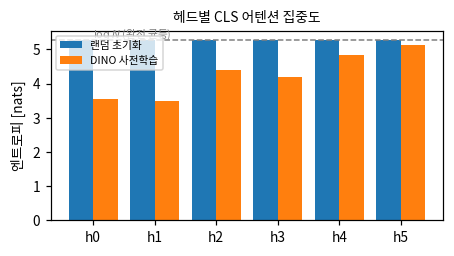

In [ ]:
rows = [("랜덤 초기화", attn_rand)] + ([("DINO 사전학습", attn_pre)] if have_pre else [])
nh = attn_rand.shape[0]
fig, ax = plt.subplots(len(rows), nh + 1, figsize=(1.6 * (nh + 1), 1.8 * len(rows)),
                       squeeze=False)
for r, (label, at) in enumerate(rows):
    ax[r][0].imshow(denorm(img[0])); ax[r][0].axis("off")
    ax[r][0].set_ylabel(label, fontsize=8)
    ax[r][0].set_title(label, fontsize=8, loc="left")
    up = F.interpolate(at.unsqueeze(0), scale_factor=PATCH_V, mode="nearest")[0].numpy()
    for h in range(nh):
        ax[r][h + 1].imshow(up[h], cmap="inferno")
        ax[r][h + 1].set_title(f"head {h}", fontsize=7)
        ax[r][h + 1].axis("off")
fig.suptitle(f"{ARCH_V}/{PATCH_V} 마지막 블록의 CLS→패치 어텐션", fontsize=9)
fig.tight_layout(); plt.show()

if have_pre:
    e_r, e_p = attn_entropy(attn_rand), attn_entropy(attn_pre)
    plt.figure(figsize=(4.2, 2.4))
    idx = np.arange(nh)
    plt.bar(idx - 0.2, e_r, 0.4, label="랜덤 초기화")
    plt.bar(idx + 0.2, e_p, 0.4, label="DINO 사전학습")
    plt.axhline(math.log(wf * wf), ls="--", c="gray", lw=1)
    plt.text(0, math.log(wf * wf) * 1.01, r"$\log N$ (완전 균등)", fontsize=7, c="gray")
    plt.xticks(idx, [f"h{i}" for i in idx]); plt.ylabel("엔트로피 [nats]")
    plt.title("헤드별 CLS 어텐션 집중도", fontsize=9); plt.legend(fontsize=7)
    plt.tight_layout(); plt.show()

 사전학습 모델의 헤드들이 **서로 다른 영역**에 집중하는 것이 보인다 —
 어떤 헤드는 객체 전체, 어떤 헤드는 특정 부위를 잡는다.
 레이블 없이 학습했는데 분할(segmentation)에 쓸 만한 마스크가 나오는 것이
 DINO 논문의 "emerging properties" 다.

 더 선명하게 보려면 patch 8 + 큰 입력을 쓴다 (§5에서 본 대로 메모리를 많이 먹는다):

 ```bash
 python visualize_attention.py --arch vit_small --patch_size 8 \
     --image_size 480 480 --threshold 0.6 --output_dir out/dino_attn
 ```

 `--threshold` 를 주면 어텐션 누적 질량 기준으로 마스크를 만들어 오버레이까지 저장한다.

 ## 13. `DINOHead` — DINO 워크스루 §4로 가는 다리

 여기까지가 backbone $f_\theta$ 였다. DINO 학습에는 그 위에 head $h_\theta$ 가 붙는다.

 ```python
 self.mlp = Sequential(Linear(in_dim, 2048), GELU,
                       Linear(2048, 2048),  GELU,
                       Linear(2048, 256))                    # nlayers=3 기본
 self.last_layer = nn.utils.weight_norm(nn.Linear(256, out_dim, bias=False))
 self.last_layer.weight_g.data.fill_(1)
 if norm_last_layer:
     self.last_layer.weight_g.requires_grad = False

 def forward(self, x):
     x = self.mlp(x)
     x = nn.functional.normalize(x, dim=-1, p=2)             # ★ 하이퍼구 투영
     x = self.last_layer(x)
     return x
 ```

 ### 왜 로짓이 코사인 유사도가 되는가

 `weight_norm` 은 각 행을 크기와 방향으로 분해한다.

 $$
 w_k = g_k \frac{v_k}{\lVert v_k \rVert}
 $$

 DINO는 $g_k = 1$ 로 채우고 `norm_last_layer=True` 면 학습에서 제외한다.
 입력도 L2 정규화되어 $\lVert \tilde{u} \rVert = 1$ 이므로

 $$
 z_k = w_k^{\top}\tilde{u} = \frac{v_k^{\top}\tilde u}{\lVert v_k\rVert}
 = \cos\angle(v_k,\ \tilde u) \in [-1, 1]
 $$

 즉 **$K$개 프로토타입 방향과의 코사인 유사도**다. 로짓 스케일이 구조적으로 $[-1,1]$ 에
 묶여 있어 특정 프로토타입이 노름을 키워 독식하는 경로가 원천 차단된다 —
 붕괴 방지의 "0번째 장치".

 `bottleneck_dim=256` 이 병목이고, 마지막 층은 $256 \times K$ 다.
 $K = 65536$ 이면 이 한 층이 16.8M — ViT-S backbone(21.7M)에 맞먹는다.

In [ ]:
for out_dim in [4096, 65536]:
    head = DINOHead(in_dim=384, out_dim=out_dim)   # ViT-S 기준
    n_mlp = sum(p.numel() for p in head.mlp.parameters())
    n_last = sum(p.numel() for p in head.last_layer.parameters())
    print(f"out_dim={out_dim:>6d}: mlp {n_mlp/1e6:5.2f}M + last_layer {n_last/1e6:6.2f}M "
          f"= {(n_mlp+n_last)/1e6:6.2f}M")
print(f"\n비교: ViT-S backbone = {sum(p.numel() for p in models['vit_small'].parameters())/1e6:.2f}M")

head = DINOHead(in_dim=D, out_dim=4096, norm_last_layer=True)
head.eval()
print(f"\nweight_g 값 전부 1? {bool((head.last_layer.weight_g == 1).all())}")
print(f"weight_g 학습됨?    {head.last_layer.weight_g.requires_grad}   (norm_last_layer=True)")
print(f"weight_v shape      {tuple(head.last_layer.weight_v.shape)}")

# ── forward 단계별 + 로짓이 코사인인지 확인
y = torch.randn(4, D)
with torch.no_grad():
    u = head.mlp(y)
    un = F.normalize(u, dim=-1, p=2)
    z = head.last_layer(un)
    z_ref = head(y)
print(f"\nmlp 출력      {tuple(u.shape)}  노름 평균 {u.norm(dim=-1).mean():.3f}")
print(f"L2 정규화     {tuple(un.shape)}  노름 {un.norm(dim=-1).mean():.4f}")
print(f"로짓          {tuple(z.shape)}  범위 [{z.min():.4f}, {z.max():.4f}]")
assert torch.allclose(z, z_ref, atol=1e-5)
assert z.abs().max() <= 1.0 + 1e-4

# 프로토타입 방향과의 코사인을 직접 계산해 비교
with torch.no_grad():
    protos = F.normalize(head.last_layer.weight_v, dim=-1, p=2)   # (K, 256)
    cos = un @ protos.t()
print(f"\n직접 계산한 cos 각도와 로짓의 최대 오차: {(cos - z).abs().max():.2e}")
assert torch.allclose(cos, z, atol=1e-4)
print("로짓 == 프로토타입 코사인 유사도 ✔  → 이제 DINO 워크스루 §4~§6 을 읽을 수 있다")

# ── norm_last_layer=False 면 스케일이 풀린다
head2 = DINOHead(in_dim=D, out_dim=4096, norm_last_layer=False)
print(f"\nnorm_last_layer=False → weight_g 학습됨? {head2.last_layer.weight_g.requires_grad}")
print("  convnet 처럼 큰 배치를 쓸 때만 풀라고 권고돼 있다 (ViT 에서는 불안정).")

out_dim=  4096: mlp  5.51M + last_layer   1.05M =   6.56M
out_dim= 65536: mlp  5.51M + last_layer  16.84M =  22.35M

비교: ViT-S backbone = 21.67M

weight_g 값 전부 1? True
weight_g 학습됨?    False   (norm_last_layer=True)
weight_v shape      (4096, 256)

mlp 출력      (4, 256)  노름 평균 0.962
L2 정규화     (4, 256)  노름 1.0000
로짓          (4, 4096)  범위 [-0.2258, 0.2397]

직접 계산한 cos 각도와 로짓의 최대 오차: 8.94e-08
로짓 == 프로토타입 코사인 유사도 ✔  → 이제 DINO 워크스루 §4~§6 을 읽을 수 있다

norm_last_layer=False → weight_g 학습됨? True
  convnet 처럼 큰 배치를 쓸 때만 풀라고 권고돼 있다 (ViT 에서는 불안정).


 ## 14. 요약 · 함정

 ### 한 장 요약

 | 모듈 | 수식 | 파라미터 | 토큰 섞음 |
 |---|---|---|---|
 | `PatchEmbed` | $z_p = W_e\,\mathrm{vec}(x_p) + b_e$ (= Conv k=s=P) | $D\cdot P^2C + D$ | 아니오 |
 | CLS + pos | $z_i \leftarrow z_i + p_i$ | $(N{+}2)D$ | 아니오 |
 | `Attention` | $\mathrm{softmax}(QK^\top/\sqrt{d_h})V$ | $4D^2 + 4D$ | **예** |
 | `Mlp` | $W_2\,\mathrm{GELU}(W_1 z)$ | $8D^2 + 5D$ | 아니오 |
 | `DropPath` | $x/(1{-}p)\cdot m$, $m\sim\mathrm{Bern}(1{-}p)$ | 0 | 아니오 |
 | `Block` | $x \mathrel{+}= \mathrm{DP}(\mathrm{Attn}(\mathrm{LN}(x)))$; $x \mathrel{+}= \mathrm{DP}(\mathrm{Mlp}(\mathrm{LN}(x)))$ | 위 합 | — |
 | `VisionTransformer` | $\mathrm{LN}(\cdots)[:,0]$ | ≈ $12D^2 \times$ depth | — |
 | `DINOHead` | $W\,\mathrm{MLP}(y)/\lVert\mathrm{MLP}(y)\rVert$ | $\approx 256K$ | 아니오 |

 ### 세 가지 크기

 | arch | embed_dim | depth | heads | head_dim | params (patch16) |
 |---|---|---|---|---|---|
 | `vit_tiny` | 192 | 12 | 3 | 64 | 5.5M |
 | `vit_small` | 384 | 12 | 6 | 64 | 21.7M |
 | `vit_base` | 768 | 12 | 12 | 64 | 85.8M |

 ### 함정

 1. **`img_size=[224]` 는 리스트다** — `img_size[0]` 으로 꺼내 쓰므로 정수를 넘기면 깨진다.
 2. **`qkv_bias` 클래스 기본값은 `False`**, 팩토리(`vit_*`)가 `True` 를 준다.
    `VisionTransformer` 를 직접 만들면 bias 없는 모델이 나온다.
 3. **`trunc_normal_(std=.02)` 는 실제로 절단하지 않는다** — `a=-2, b=2` 가 절대 경계라
    $\pm100\sigma$ 에 놓인다.
 4. **`Attention.forward` 는 튜플 `(x, attn)` 을 반환한다** — 다른 ViT 구현과 달라
    그대로 갈아끼우면 깨진다. `MultiCropWrapper` 가 XCiT 때문에 `isinstance(_out, tuple)` 을
    검사하는 것도 이런 이유다.
 5. **`patch_size` 는 파라미터를 안 늘리지만 연산량을 16배로 늘린다** (patch16 → 8).
    어텐션 행렬 $(B,\text{heads},N,N)$ 가 항상 materialize 되므로 OOM의 주범.
 6. **`num_classes=0` 이라 `head` 는 `Identity`** — DINO 백본에는 분류기가 없다.
 7. **pre-norm 이라 마지막 블록 출력은 정규화돼 있지 않다** → `self.norm` 을 따로 적용해야 한다.
    `get_intermediate_layers` 도 각 중간 출력에 이 `norm` 을 적용한다.

 ### 다음 단계

 - **[dino_training_walkthrough.py](dino_training_walkthrough.py) §4 부터** — 이제 backbone과
   DINOHead의 내부를 알고 있으니 `MultiCropWrapper`, `DINOLoss`, centering/sharpening으로 넘어간다.
 - 실행 명령 모음: [SAMPLES.md](../SAMPLES.md)
 - ViT 원 논문: [arXiv:2010.11929](https://arxiv.org/abs/2010.11929) / DINO: [arXiv:2104.14294](https://arxiv.org/abs/2104.14294)